--- Auditoría de Datos (EDA) ---
Total de filas y columnas: (7043, 21)



C:\Users\basti\AppData\Local\Temp\ipykernel_10144\3020701348.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='pastel')


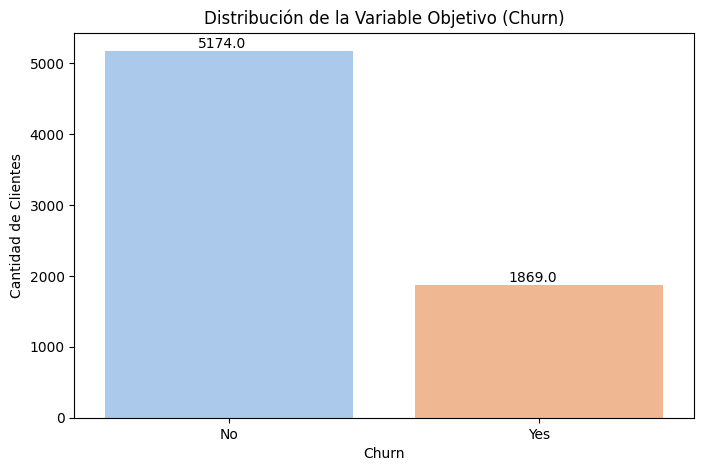

C:\Users\basti\AppData\Local\Temp\ipykernel_10144\3020701348.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='pastel')


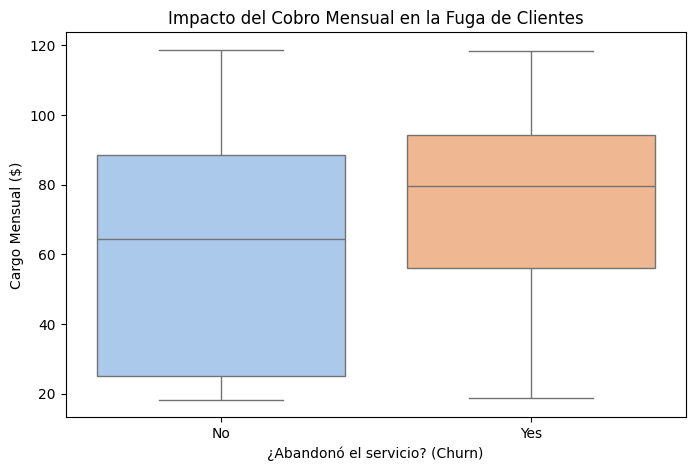

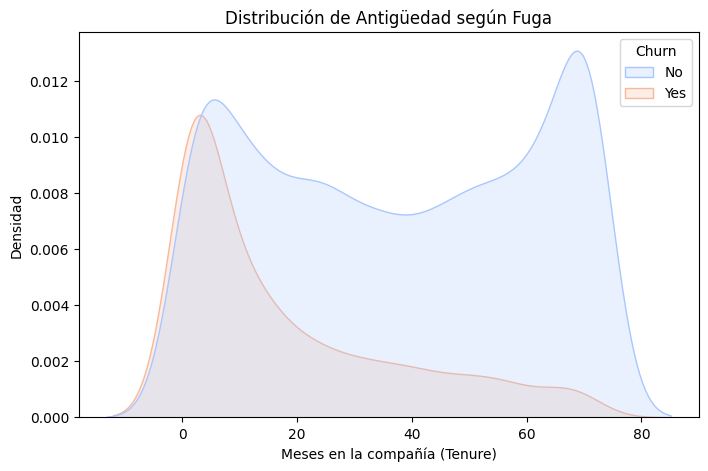

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# 1. Cargar los datos crudos (Raw) directamente
BASE_DIR = Path(os.getcwd()).parent
raw_path = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(raw_path)

print("--- Auditoría de Datos (EDA) ---")
print(f"Total de filas y columnas: {df.shape}\n")

# 2. Transformación inicial de la columna defectuosa
# (Requisito fundamental antes de graficar)
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 3. Visualización 1: ¿Están desbalanceadas las clases?
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Churn', palette='pastel')
plt.title('Distribución de la Variable Objetivo (Churn)')
plt.ylabel('Cantidad de Clientes')

# Agregar los números exactos sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 50))
plt.show()

# 4. Visualización 2: Análisis Bivariado (Cargos Mensuales vs Fuga)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='pastel')
plt.title('Impacto del Cobro Mensual en la Fuga de Clientes')
plt.xlabel('¿Abandonó el servicio? (Churn)')
plt.ylabel('Cargo Mensual ($)')
plt.show()

# 5. Visualización 3: Antigüedad (Tenure) vs Fuga
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='coolwarm')
plt.title('Distribución de Antigüedad según Fuga')
plt.xlabel('Meses en la compañía (Tenure)')
plt.ylabel('Densidad')
plt.show()